<a href="https://colab.research.google.com/github/Naman1232/ML-PROJECTS/blob/main/Data_Augmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage import io
import numpy as np
import matplotlib.pyplot as plt



*   from tensorflow.keras.preprocessing.image import ImageDataGenerator
This imports the ImageDataGenerator class from TensorFlow Keras, which is used to perform real-time data augmentation on images. It can apply random transformations like rotation, flipping, zooming, etc., to your training images to increase data diversity.

*   
from skimage import io
Imports the io module from the scikit-image library, which provides functions for reading and saving images. Here, it’s typically used to load images from disk into arrays.



In [ ]:
from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
x = io.imread(filename)
x = np.expand_dims(x, axis=0)

Saving einstein.png to einstein.png


Explanation:

x is usually a 3D array representing a single image with shape (height, width, channels).

np.expand_dims(x, axis=0) adds a new dimension at position 0.

This changes the shape of x from (height, width, channels) to (1, height, width, channels).

Why do this?

Most deep learning models and functions like ImageDataGenerator.flow() expect a batch of images, even if it's just one image. The extra dimension at axis 0 represents the batch size.

So this converts a single image into a batch containing one image.

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=45,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='reflect'
)



Shear range in data augmentation tilts or slants images sideways by a small angle, creating distorted versions. This helps models learn to recognize objects even if they appear skewed or angled differently.


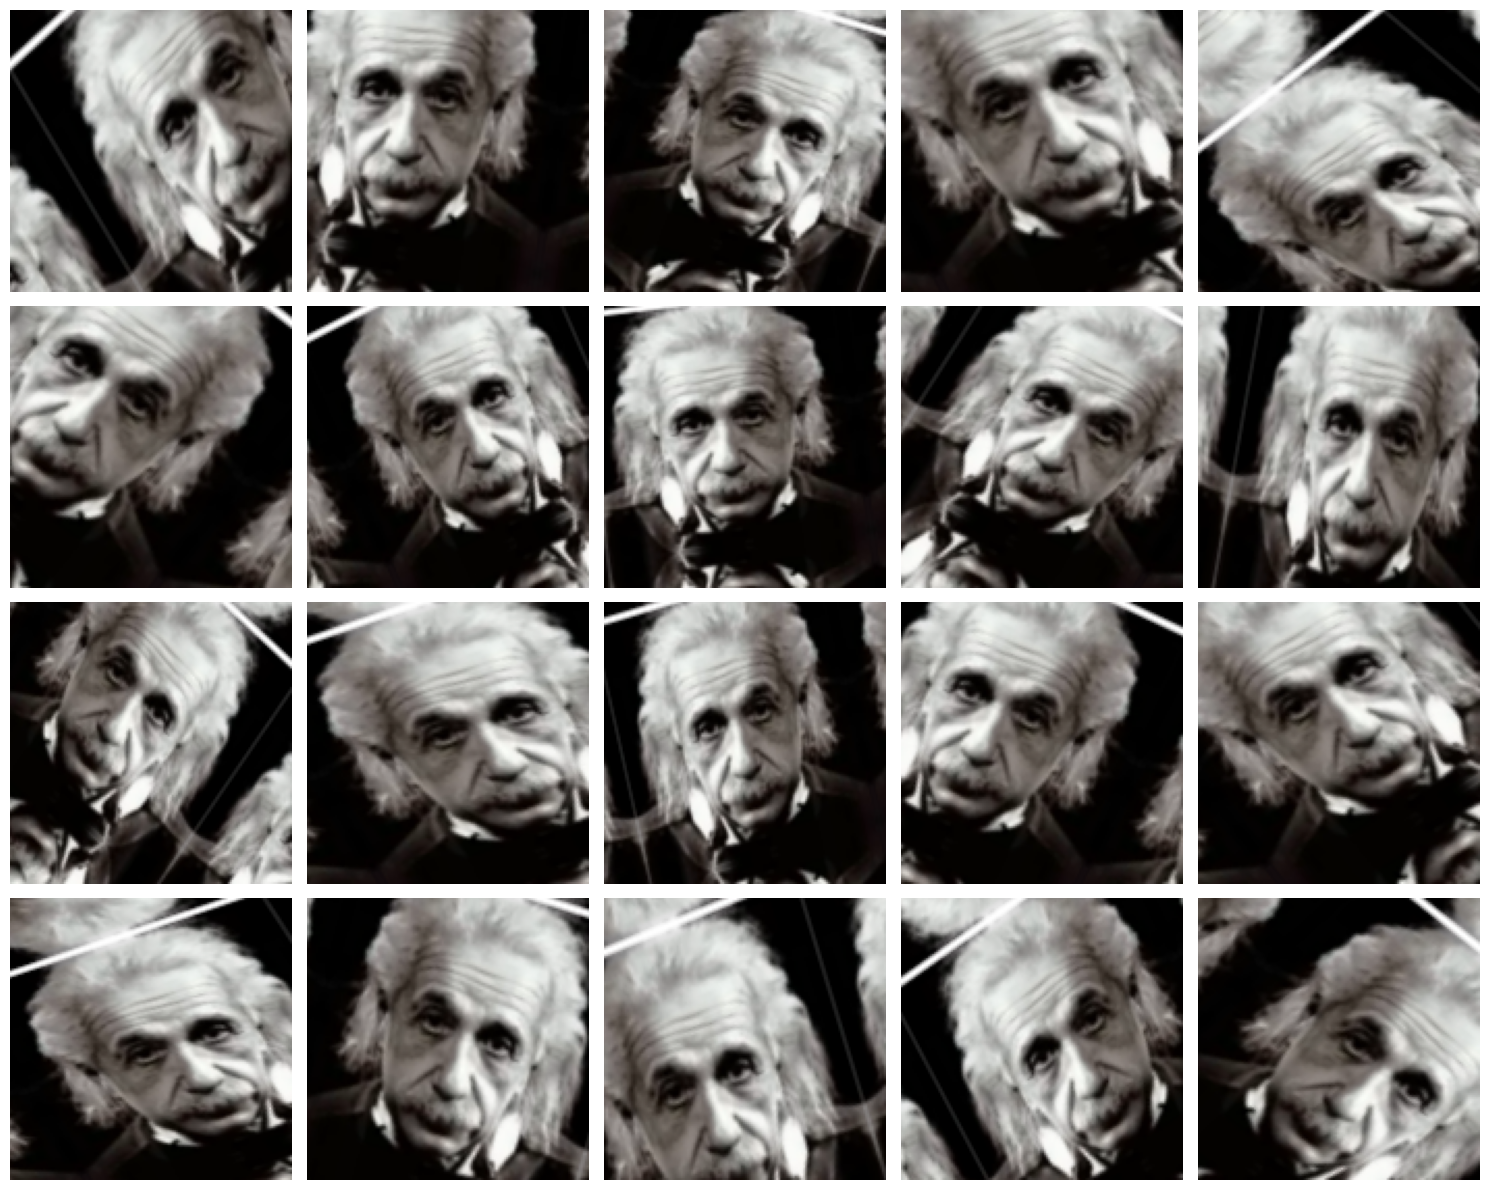

In [ ]:
i = 0
fig, axes = plt.subplots(4, 5, figsize=(15, 12))

for batch in datagen.flow(x, batch_size=1):
    ax = axes[i // 5, i % 5]
    ax.imshow(batch[0].astype('uint8'))
    ax.axis('off')
    i += 1
    if i >= 20:
        break

plt.tight_layout()
plt.show()